In [2]:
from src.run_app import *
from src.prepare_gam import *
from src.utils import *
from gam_rs_utils.binarize_dataset import binarize_dataset
import pickle as pkl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import defaultdict
from tqdm import tqdm

In [ ]:
# load the dataset
dataset_name = 'bank'
path = 'datasets/{}.csv'.format(dataset_name)
dataset = pd.read_csv(path)
df, thresholds, header, threshold_guess_time = binarize_dataset(dataset, 100)
X, y = df.iloc[:, :-1], df.iloc[:, -1]

header = list(X.columns)
header = pd.Index(["intercept"] + header)
header = header.astype("object")

X_one_hot, y = utils.get_X_y(X, y)

print("header dimension", len(header), flush=True)
print(X_one_hot.shape, y.shape)

header dimension 38
(4521, 38) (4521,)


In [9]:
from FasterRisk.src.fasterrisk import fasterrisk

## example using 3 swaps ###
rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.006, select_top_m=100)
rs.optimize(generate_non_integer_solution=True, test=True, swaps=5)
beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

# # save betas and beta0 to a pickle file
# with open("compas_0.008_3.pkl", "wb") as f:
#     pkl.dump({"betas": betas, "beta0": beta0}, f)

# ### example with 2 swaps ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=2)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

### example with 1 swap ###
# rs = fasterrisk.RiskScoreOptimizer(X_one_hot, y, k=10, lb=-100, ub=100, gap_tolerance=0.002, select_top_m=100)
# rs.optimize(generate_non_integer_solution=True, test=True, swaps=1)
# beta0, betas = rs.sparseDiversePool_beta0, rs.sparseDiversePool_betas

[ 6  7  8 12 13 18 23 29 34 36]
0
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 2 solutions, 2 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 2 solutions, 2 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 1 solutions, 1 of them were diverse
there were 2 solutions, 2 

In [10]:
print(f"found {betas.shape[0]} models")
mean_loss = 0
for i in range(len(betas)):
    wi = betas[i, :]
    intercepti = beta0[i]
    logit = X_one_hot @ wi + intercepti
    y_pred = np.exp(logit) / (1 + np.exp(logit))
    y_pred = np.where(y_pred > 0.5, 1, -1)
    mean_loss += (y != y_pred).mean()
    print(np.nonzero(wi)[0], (y != y_pred).mean())
print(mean_loss / len(betas))

found 100 models
[ 2  4  8 12 13 14 18 22 29 37] 0.10550763105507631
[ 5  6  8 12 13 15 19 24 29 35] 0.10816191108161911
[ 5  6  7  8 13 15 19 22 29 33] 0.10771953107719531
[ 2  5  6  8 13 14 19 23 29 35] 0.1074983410749834
[ 4  7  8 12 13 14 17 24 29 35] 0.10595001105950011
[ 2  5  8 12 13 14 17 23 29 37] 0.1070559610705596
[ 2  5  6  8 13 14 18 24 29 37] 0.10838310108383101
[ 5  6  8 13 14 19 23 29 30 33] 0.1066135810661358
[ 6  8 12 13 15 19 24 29 31 37] 0.1032957310329573
[ 5  8 12 13 14 18 22 29 31 33] 0.10263216102632161
[ 4  8 12 13 14 19 23 29 31 35] 0.10307454103074541
[ 5  7  8 12 13 15 17 24 29 37] 0.1066135810661358
[ 4  7  8 12 13 14 19 24 30 36] 0.1041804910418049
[ 4  8 12 13 14 19 22 29 35 36] 0.10572882105728822
[ 5  8 12 13 14 18 22 29 30 35] 0.1037381110373811
[ 2  5  8 12 13 15 18 24 29 33] 0.1066135810661358
[ 6  8 12 13 15 17 22 29 30 37] 0.10307454103074541
[ 4  6  8 13 15 18 22 29 30 33] 0.1032957310329573
[ 4  6  8 13 15 18 22 29 30 35] 0.1032957310329573
[ 4  

100%|██████████| 100/100 [00:00<00:00, 487.26it/s]


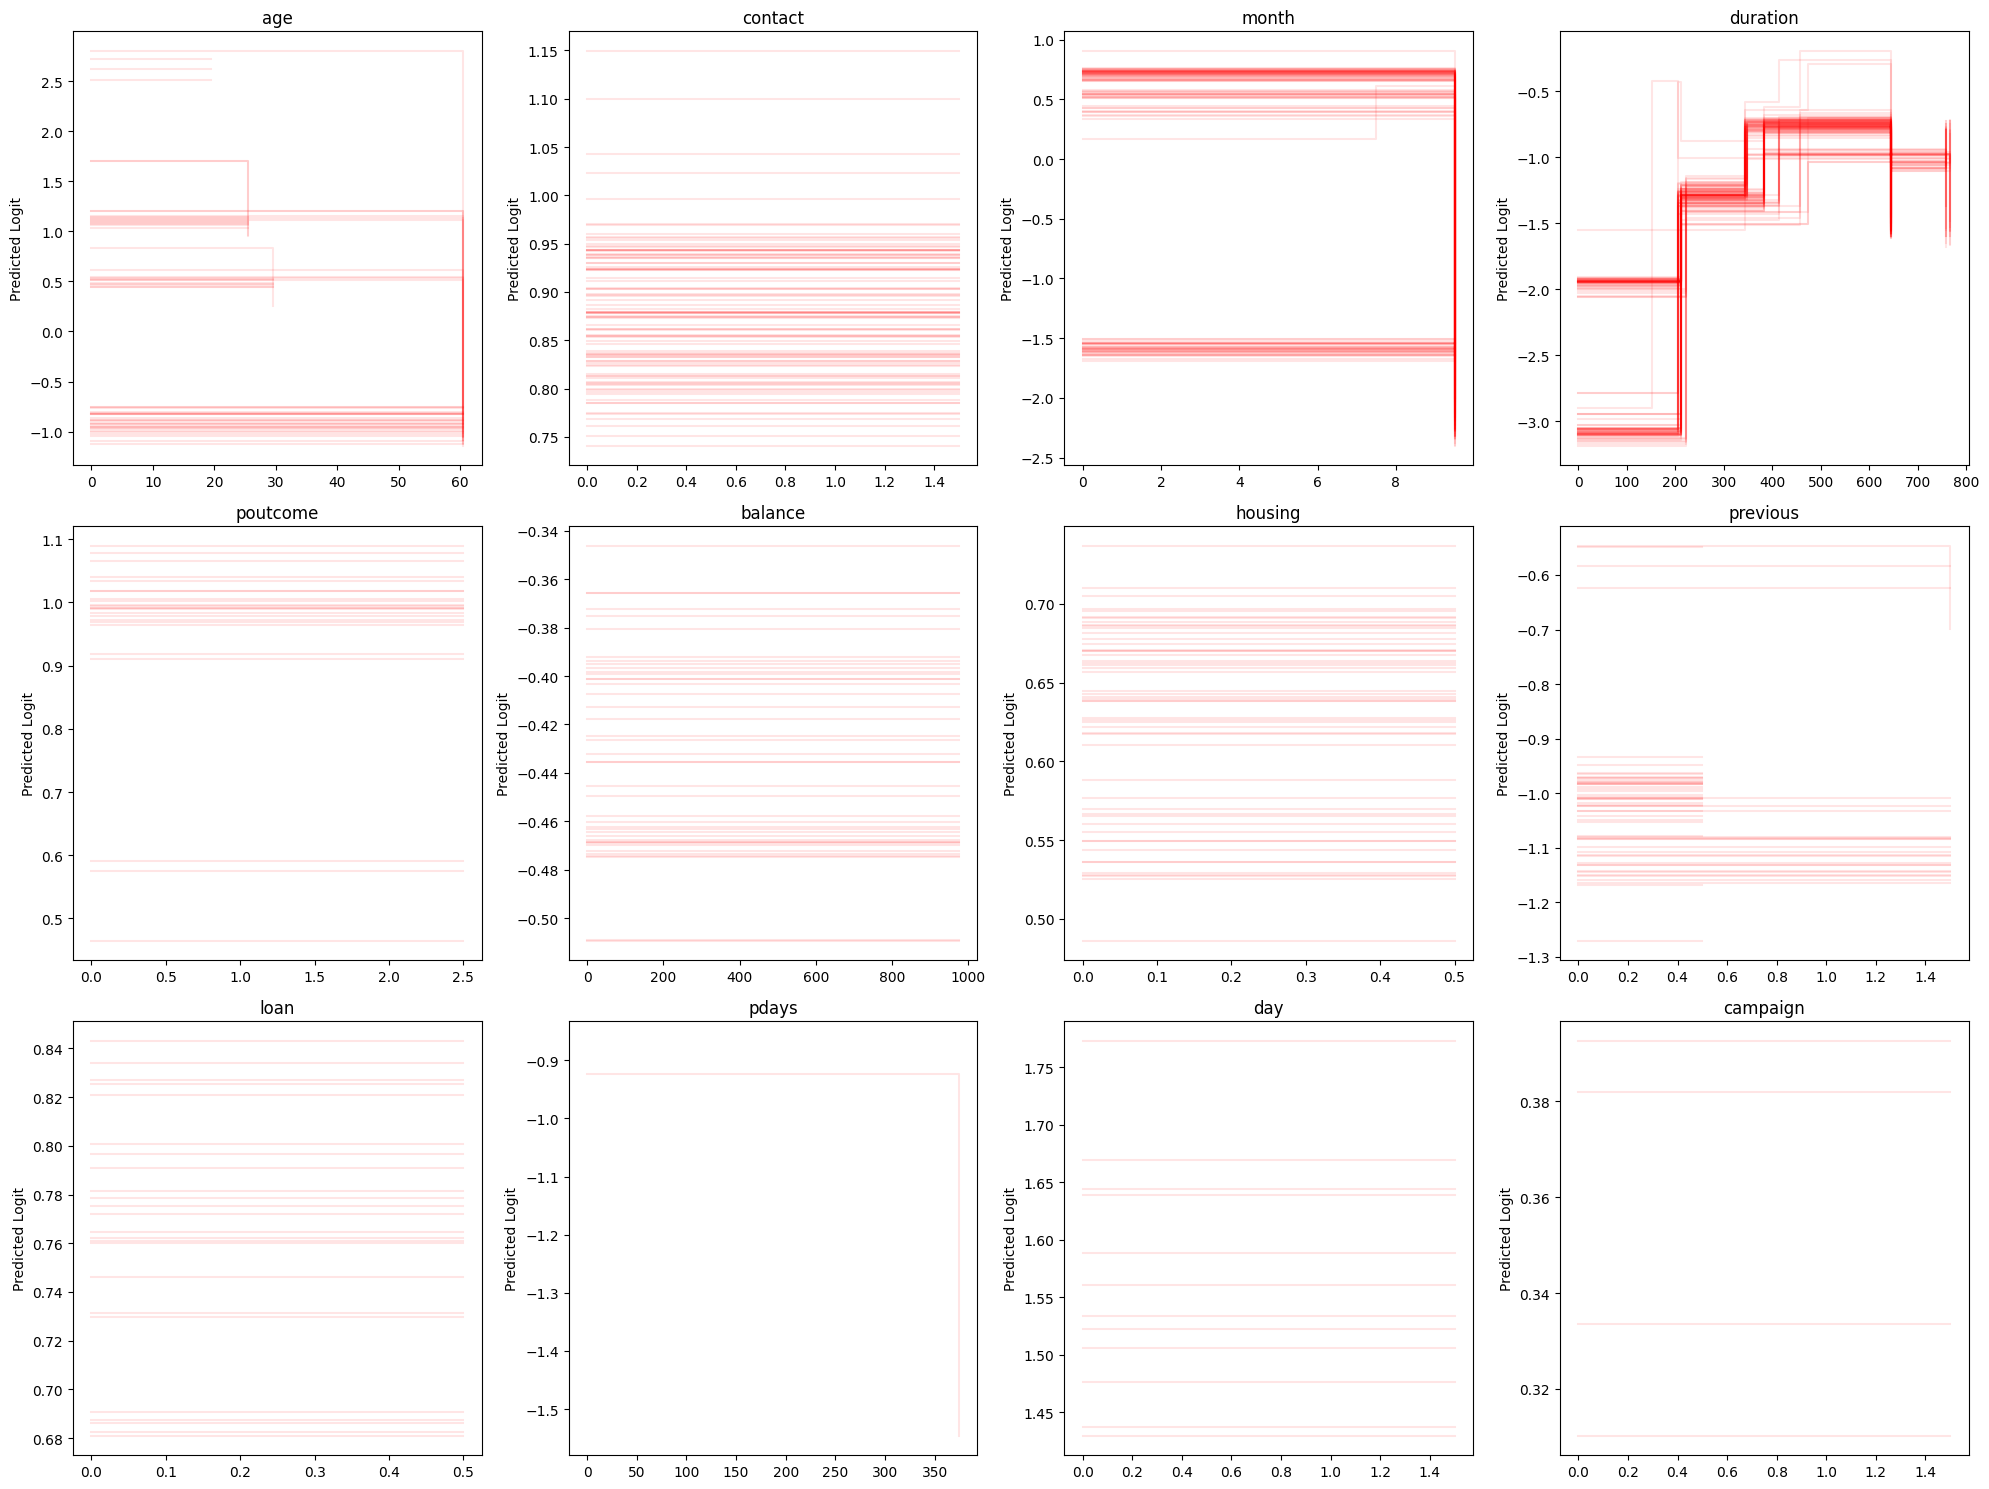

In [11]:
def get_feature_thresholds(weights, columns):
    feature_thresholds = defaultdict(list)
    for col, weight in zip(columns, weights):
        match = re.search(r'([a-zA-Z]+)', col)
        if match:
            feature = match.group(1)
            threshold = re.findall(r'[\d.]+', col)
            if feature == 'juv':
                feature = 'juv_misd_count'
            if feature == 'juvenile':
                feature = 'juvenile_crimes'
            feature_thresholds[feature].append((list(map(float, threshold)), weight))
    return feature_thresholds

def plot_gam(header, list_of_weights):
    rows = 3; cols = 4
    fig, axs = plt.subplots(nrows=rows, ncols=cols, figsize=(5 * cols, 5 * rows))
    axs = axs.flatten()
    ax_dict = {}
    counter = 0
    union_of_support_sets = defaultdict(int)
    for i in tqdm(range(len(list_of_weights))):
        weights = list_of_weights[i, :]
        columns = header[np.nonzero(weights)[0]]
        weights = weights[np.nonzero(weights)[0]]
        for column in columns:
            union_of_support_sets[column] += 1

        feature_thresholds = get_feature_thresholds(weights, columns)
        for feature, thresholds_weights in feature_thresholds.items():
            if feature == 'sex' or feature == 'current':
                continue
            if feature not in ax_dict:
                ax = axs[counter]
                ax_dict[feature] = ax
                counter += 1
            else:
                ax = ax_dict[feature]
            thresholds, feature_weights = zip(*thresholds_weights)

            x_vals, y_vals = [], []
            x_vals.append(0)
            y_vals.append(feature_weights[0])
            for i in range(len(thresholds) - 1):
                x_vals.append(thresholds[i][0])
                y_vals.append(feature_weights[i])

            # For the last value of the interval, add it once more
            x_vals.append(thresholds[-1][-1])
            y_vals.append(feature_weights[-1])

            ax.step(x_vals, y_vals, where="post", color='r', alpha=0.1)
            ax.set_ylabel("Predicted Logit")
            ax.set_title(feature)
    plt.tight_layout()
    plt.show()
    return union_of_support_sets

union_of_support_sets = plot_gam(header, betas[:100, :])

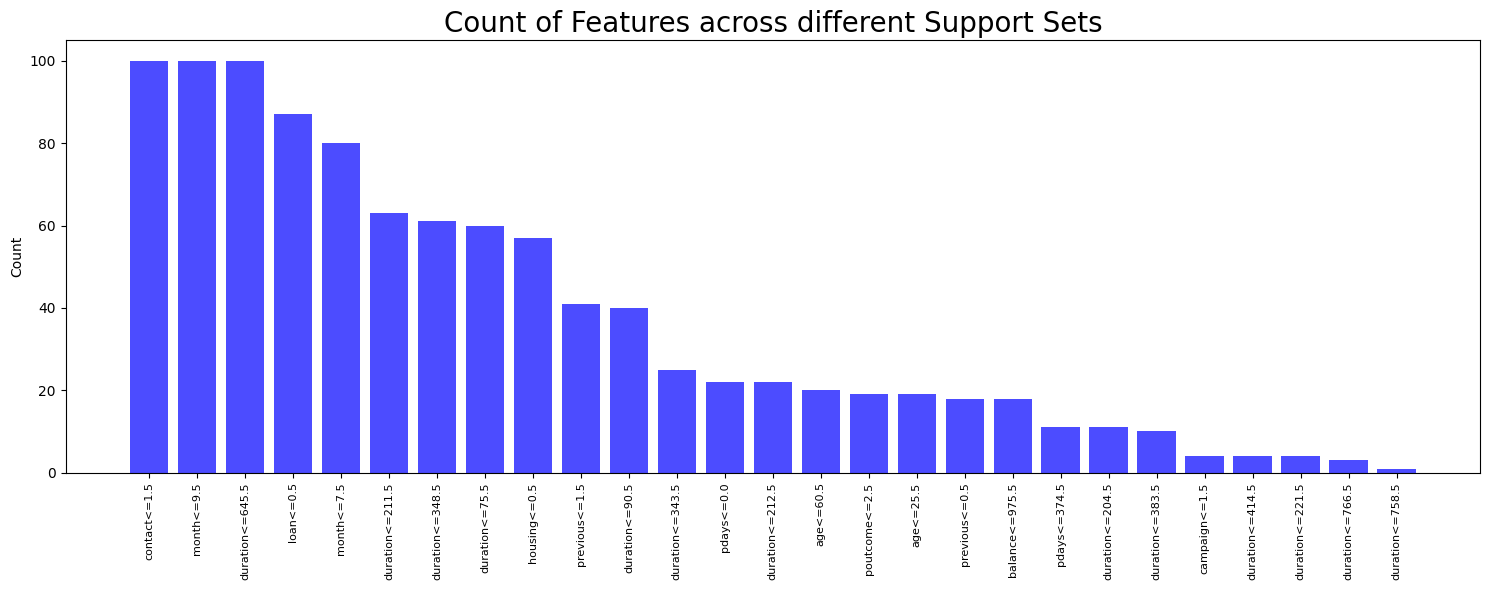

In [6]:
# Given dictionary
sorted_data = dict(sorted(union_of_support_sets.items(), key=lambda x: x[1], reverse=True))

# Prepare data for histogram
keys = list(sorted_data.keys())
values = list(sorted_data.values())

# Plot histogram
plt.figure(figsize=(15, 6))
plt.bar(keys, values, color='blue', alpha=0.7)
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Count')
plt.title('Count of Features across different Support Sets', fontsize=20)
plt.tight_layout()
plt.show()